## Verifying ESCI "Exact" Labels with Local LLMs 
### Iterative prompt engineering on Gemma:4b through Ollama

The ESCI dataset labels query-product pairs as 'E' when the product satisfies all query specifications. However, some labels are incorrect i.e.
**Product information explicitly contradicts a query requirement, despite being labeled as an exact match**
 
**Target Queries:**
1. `"aa batteries 100 pack"`
2. `"kodak photo paper 8.5 x 11 glossy"`
3. `"dewalt 8v max cordless screwdriver kit, gyroscopic"`

**Key Rules:**
- **Missing info != conflict**
- **Extra info != conflict**
- **Explicit contradiction == conflict**

**Approach**: 
I use a local LLM via Ollama with structured Pydantic output schemas to automatically detect these conflicts, iterating through 3 prompt versions systematically
fixing failures.

### Step 0: Data Audit and Labeling
1. **Dataset Exploration**: Examined both `examples` 2.6M query-product judgements and `products` (1.8M product records) parquet files. 
2. **Join key validation**: Confirmed that `(product_locale, product_id)` forms a unique identifier for product records — the same product can exist in multiple locales with different descriptions (verified in [`00_first_pass_audit.ipynb`](./00_first_pass_audit.ipynb))
3. **Manual labeling**: Labeled all 24 query-product pairs (filtered to our 3 target queries with `esci_label='E'`) to create a human ground truth for evaluating LLM performance. Of the 24 pairs, **8 have genuine conflicts** and **16 are correct "E" labels**

### Step 1: Data Loading and Preparation

1. **Raw data**: 2.6M query-product judgments + 1.8M product records
2. **Merging**: Left join on `(product_locale, product_id)` to attach full product context (title, bullets, brand, description) to every judgment
3. **Filtering**: Restrict to target queries + `esci_label='E'` → **24 evaluation pairs**
4. **Random sample**: 5 additional "E"-labeled pairs drawn randomly from the full dataset (multi-locale, multi-language) to stress-test generalizability

In [1]:
from src.llm import ModelEvaluator
from src.prompts import EVALUATION_PROMPT_V2, EVALUATION_PROMPT, PASS1_PROMPT, PASS2_PROMPT
from src.evalution import run_experiment, score_against_human, run_two_pass, show
from src.data_loader import load_raw_data, merge_examples_products, filter_dataset
from src.schemas.response_schema import MyResponse, MyResponseV2, Pass1Response, Pass2Response
from pathlib import Path
import pandas as pd

In [2]:
# df_examples, df_products = load_raw_data('../data/raw')
# df_merged = merge_examples_products(df_examples, df_products)
# subset = filter_dataset(df_merged)
# random_sample_df = df_merged[df_merged.esci_label =='E'].sample(5, random_state=42)

subset = pd.read_csv('../data/processed/subset_to_review.csv')
manual_labels = pd.read_csv('../data/processed/my_manual_labels.csv')
random_sample_df = pd.read_csv('../data/processed/random_sample.csv')

### Step 2: Prompt Engineering

I iterate through three prompt/schema versions. Each version is motivated by specific failure analysis from the previous one:
| Version | Key Change | Result |
|---------|-----------|--------|
| **V0** | Structured CoT baseline | 79% accuracy |
| **V2** | Two-pass: extract then judge | 88% accuracy |

#### V0: Structured Chain-of-Thought Baseline (Gemma3:4b)

**Key Design Decisions**:

1. **Structured output over free text**: Instead of asking the LLM a simple yes/no, the prompt forces a structured, chain-of-thought output via a Pydantic schema (`MyResponse`). This makes the model reason step-by-step before committing to a decision
2. **LiteLLM as a wrapper**: Allows swapping models with a single parameter change — no code changes needed to try Gemma, Qwen, Gemini, etc.
3. **Pydantic response schemas**: Passed directly to the model via LiteLLM's `response_format` parameter, ensuring strict JSON output that can be programmatically parsed and evaluated
4. **Reusable evaluation framework**: `ModelEvaluator` + `run_experiment()` + `score_against_human()` let me compare any prompt/model combination against the human ground truth with one line of code

**The V0 Schema (`MyResponse`) forces the LLM to output**:
1. `query_features` — Parse the query into individual specs (e.g., `["aa batteries", "100 pack"]`)
2. `product_features` — Extract the corresponding features from product text
3. `conflict_found` — Boolean: does any product attribute explicitly contradict a query attribute?
4. `reasoning` — Explain the decision
5. `reformulated_query` — If conflict found, rewrite the query to match the product

**Conflict rules embedded in the prompt** (`EVALUATION_PROMPT`):
- Only flag a conflict if the product **explicitly states a different value** for the same attribute (quantity, size, finish, brand, inclusions/exclusions)
- Missing information → assume match (not a conflict)
- Extra info in product → still a match



Code files:
1. [`response_schema.py`](../src/schemas/response_schema.py): Pydantic Schema
2. [`llm.py`](../src/llm.py): Wrapper around litellm
3. [`evaluation.py`](../src/evalution.py): Eval Code
4. [`prompts.py`](../src/prompts.py): Prompts

In [3]:
if Path('../data/processed/gemma_labels_v0.csv').exists():
    v0_labels = pd.read_csv('../data/processed/gemma_labels_v0.csv')
    v0_random_sample_labels = pd.read_csv('../data/processed/gemma_random_labels_v0.csv')
else:
    gemma_v0 = ModelEvaluator(temperature=0)
    v0_labels = run_experiment(subset, gemma_v0, 'gemma_labels_v0')
    v0_random_sample_labels = run_experiment(random_sample_df, gemma_v0, 'gemma_random_labels_v0')

merged_data = pd.merge(
    v0_labels,
    manual_labels.loc[:, ['example_id', 'human_label', 'human_notes', 'Conflict_Found_GT']],
    how='inner', on='example_id'
)

#### V0 Error Analysis

Examining the cases where the model disagrees with human labels reveals three distinct failure modes:

In [4]:
# Wrong cases 
show(merged_data[merged_data.conflict_found != merged_data.Conflict_Found_GT])

,example_id,query,title,human_label,Conflict_Found_GT,conflict_found,reasoning,reformulated_query,error
5,142661,aa batteries 100 pack,Energizer AA Max Alkaline E91 Batteries Made in USA - Expiration 12/2024 or Later - 100 Count,S,True,False,"The query asks for ""aa batteries 100 pack"". The product explicitly states ""Energizer MAX AA batteries 50 count"", but the product also states ""100 count"". Since the product includes the quantity, we assume it is a match. The product also includes the brand name ""Energizer"" which is present in the query.",nan,nan
7,142666,aa batteries 100 pack,"Amazon Basics 100 Pack AAA High-Performance Alkaline Batteries, 10-Year Shelf Life, Easy to Open Value Pack",S,True,False,"The query asks for 'aa batteries 100 pack'. The product specifies 'aaa' batteries, but the quantity (100 pack) matches. The voltage (1.5 volt) and battery type (alkaline) also match. The brand 'amazon basics' is also present in the product description. The product explicitly states that the batteries are not rechargeable, which is not a contradiction.",aaa batteries 100 pack,nan
10,660833,"dewalt 8v max cordless screwdriver kit, gyroscopic","DEWALT DCF680N2 8V Max Gyroscopic Screwdriver 2 Battery Kit with DEWALT DWST08201 Tough System Case, Small",E,False,True,"The query explicitly asks for an 8v max cordless screwdriver kit. The product title and bullet points confirm this, stating ""DEWALT DCF680N2 8V Max Gyroscopic Screwdriver 2 Battery Kit"".","dewalt 8v max cordless screwdriver 2 battery kit, gyroscopic",nan
12,660840,"dewalt 8v max cordless screwdriver kit, gyroscopic","DEWALT 8V MAX Cordless Screwdriver Kit, Gyroscopic, 2 Batteries, Electric (DCF680N2)",E,False,True,"The query specifies an 8v max kit. The product explicitly states it is an 8V MAX Cordless Screwdriver Kit. No contradiction on ""gyroscopic"" so we leave it in the reformulated query.","dewalt 8v max cordless screwdriver kit, gyroscopic",nan
21,1163641,kodak photo paper 8.5 x 11 glossy,"Kodak Photo Paper for inkjet printers, Matte Finish, 7 mil thickness, 100 sheets, 8.5” x 11” (8318164)",S,True,False,"The query asks for glossy photo paper, but the product is matte finish. There is no contradiction on the size or quantity. The brand name is also correct. Therefore, it is a match.",nan,nan


#### V0 Failure Cases

**Failure 1 — Intra-product contradiction missed (example_id: 142661)**
- **Query**: "aa batteries 100 pack"
- **Product title**: "Energizer AA Max Alkaline...100 Count" / **Bullet points**: "Energizer MAX AA batteries **50 count**"
- **What happened**: The title says 100 count but bullet points say 50 count. The model saw both values and concluded "since the product includes the quantity, we assume it is a match"
- **Root cause**: V0 has no rule for handling contradictions *within* the product itself (title vs. bullets)

**Failure 2 — Logical inconsistency between reasoning and decision (example_id: 660833)**
- **Query**: "dewalt 8v max cordless screwdriver kit, gyroscopic"
- **What happened**: Model's reasoning says *"The query explicitly asks for an 8v max cordless screwdriver kit. The product title and bullet points confirm this"* — then **still sets `conflict_found=True`**
- **Root cause**: In V0, the `conflict_found` boolean field comes *before* `reasoning` in the schema. The model commits to a boolean before articulating its logic, leading to inconsistency

**Failure 3 — Glossy vs. Matte not caught (example_id: 1163641)**
- **Query**: "kodak photo paper 8.5 x 11 glossy"
- **Product**: "Kodak Photo Paper...Matte Finish"
- **What happened**: Model's reasoning acknowledges *"the query asks for glossy photo paper, but the product is matte finish"* — yet concludes *"Therefore, it is a match"*
- **Root cause**: The redundant `acceptable` field (which is just `NOT(conflict_found)`) creates confusion. The model can set `conflict_found=False` while noting the contradiction in reasoning

##### V0 Performance vs. Human Labels

              precision    recall  f1-score   support

 No Conflict       0.82      0.88      0.85        16
    Conflict       0.71      0.62      0.67         8

    accuracy                           0.79        24
   macro avg       0.77      0.75      0.76        24
weighted avg       0.79      0.79      0.79        24



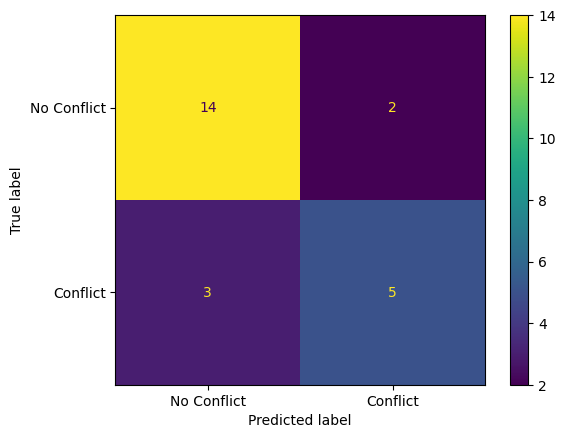

In [7]:
score_against_human(merged_data)

##### V0 on Random Sample (Generalizability Check)

In [8]:
# Checking a random sample
show(v0_random_sample_labels, display_cols= ["example_id", "query", "title", "conflict_found", "reasoning", "reformulated_query", "error"])

,example_id,query,title,conflict_found,reasoning,reformulated_query,error
0,2498421,収納ボックス,アイリスオーヤマ チェスト ワイド 3段 日本製 完成品 幅54×奥行40×高さ62.5cm ホワイト / クリア 白 プラスチック天板 W-543,False,"The query is asking for a '収納ボックス' (storage box). The product title clearly states it is a 'チェスト ワイド 3段' (wide 3-tier chest), which is a type of storage box. There is no contradiction.",チェスト ワイド 3段 日本製 完成品 幅54×奥行40×高さ62.5cm ホワイト / クリア 白 プラスチック天板 W-543,nan
1,706866,dr martens mujer plataforma,"Botas para mujer, color Negro , marca DR. MARTENS, modelo Botas Para Mujer DR. MARTENS SINCLAIR 8 EYE AUNT S Negro",False,"The query asks for ""dr martens mujer plataforma"". The product explicitly states ""These platform boots..."" and ""5 cm heel and 3.5 cm platform"", so there is no contradiction. The query also includes ""mujer"" which is present in the product title and description.",nan,nan
2,1982138,tempered glass privacy screen iphone xr,"Hizansa [2 Pack] iPhone Xs Max Screen Protector,6D Tempered Glass Screen Protector for iPhone Xs Max (iPhone Xs Max)",False,"The product is designed for iPhone Xs Max, not iPhone XR. The query asks for an iPhone XR screen. This is a difference in device model, not a contradiction of features. The product includes tempered glass and privacy screen, which are present in the query. The product also includes features like 9H hardness, anti-fingerprint coating, and shatter-proof, which are present in the query. The product also includes ""double defense technology"" which is present in the query. The product does not explicitly state that it is a privacy screen, but the product description mentions ""protects sensors and front camera"" which is a common feature of privacy screens. Therefore, there is no contradiction.",tempered glass privacy screen iphone xs max,nan
3,313103,belly button rings,EVELICAL 15Pcs 14G Stainless Steel Belly Button Rings for Women Girls CZ Screw Navel Bars Body Piercing Jewelry,False,"The query asks for 'belly button rings'. The product description explicitly states '15Pcs 14G Stainless Steel Belly Button Rings for Women Girls CZ Screw Navel Bars Body Piercing Jewelry'. There is no contradiction, so it is a match.",nan,nan
4,2512267,存在のたえられない軽さ,存在の耐えられない軽さ(字幕版),False,The query and product share the same title. There is no contradiction.,nan,nan


#### V1: Feature Alignment + Schema Reordering (Gemma3:4b)
V1 addresses the three failure modes identified in V0 through prompt and schema changes:

Solved some problems, but the model still struggles to match and verify features. For example, 8.5 * 11 and 8-1/2 * 11 is brought up as a contradiction

              precision    recall  f1-score   support

 No Conflict       0.93      0.81      0.87        16
    Conflict       0.70      0.88      0.78         8

    accuracy                           0.83        24
   macro avg       0.81      0.84      0.82        24
weighted avg       0.85      0.83      0.84        24



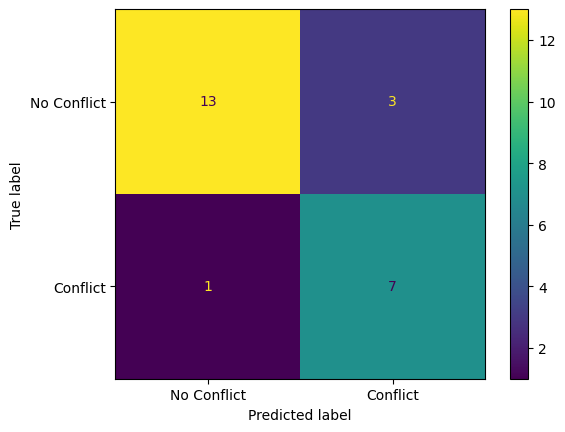

In [9]:
if Path('../data/processed/gemma_labels_v1.csv').exists():
    v1_labels = pd.read_csv('../data/processed/gemma_labels_v1.csv')
    v1_random_sample_labels = pd.read_csv('../data/processed/gemma_random_labels_v1.csv')
else:
    gemma_v1 = ModelEvaluator(temperature=0, response_schema=MyResponseV2, 
        system_prompt=EVALUATION_PROMPT_V2, num_retries=3)
    v1_labels = run_experiment(subset, gemma_v1, 'gemma_labels_v1')
    v1_random_sample_labels = run_experiment(random_sample_df, gemma_v1, 'gemma_random_labels_v1')

merged_data_v1 = pd.merge(
    v1_labels,
    manual_labels.loc[:, ['example_id', 'human_label', 'human_notes', 'Conflict_Found_GT']],
    how='inner', on='example_id'
)
score_against_human(merged_data_v1)

In [10]:
show(merged_data_v1[merged_data_v1.conflict_found != merged_data_v1.Conflict_Found_GT])

,example_id,query,title,human_label,Conflict_Found_GT,conflict_found,reasoning,reformulated_query,error
11,660838,"dewalt 8v max cordless screwdriver kit, gyroscopic",DEWALT DCB095 8V MAX Battery Charger,C,True,False,"The product title and bullet points confirm the 8V MAX battery charger. The query asks for a 'cordless screwdriver kit' and 'gyroscopic', but the product does not mention 'gyroscopic'. Therefore, we assume it is a match. No contradiction found.",dewalt 8v max cordless screwdriver kit,nan
16,1163633,kodak photo paper 8.5 x 11 glossy,"Photo Paper, 6.5 mil, Glossy, 8-1/2 x 11, 100 Sheets/Pack",E,False,True,"The query asks for Kodak photo paper 8.5 x 11 glossy. The product is Kodak photo paper 6.5 mil, glossy, 8-1/2 x 11, 100 Sheets/Pack. The query and product match on brand and glossiness. However, the query specifies 8.5 x 11, while the product specifies 8-1/2 x 11. This is a contradiction. Therefore, the reformulated query is: ""kodak photo paper 8-1/2 x 11 glossy""",kodak photo paper 8-1/2 x 11 glossy,nan
17,1163634,kodak photo paper 8.5 x 11 glossy,"Kodak 8209017 Photo Paper, 6.5 mil, Glossy, 8-1/2 x 11, 100 Sheets/Pack",E,False,True,"The query asks for Kodak photo paper in 8.5 x 11 glossy format. The product matches the brand 'Kodak' and the size '8-1/2 x 11'. However, the product specifies '6.5 mil' thickness, which contradicts the query's '8.5 x 11' size. Therefore, a conflict is found and the query is reformulated to reflect the product's specifications.",kodak photo paper 8-1/2 x 11 glossy 6.5 mil,nan
18,1163638,kodak photo paper 8.5 x 11 glossy,"Kodak Photo Paper for inkjet printers, Gloss Finish, 7 mil thickness, 50 Sheets, 8.5” x 11” (1213712)",E,False,True,"The query asks for Kodak photo paper 8.5 x 11 glossy. The product matches the brand Kodak, but the dimensions are 8.5” x 11” instead of 8.5 x 11. The finish is gloss finish instead of glossy. Therefore, a conflict is found.","kodak photo paper 8.5” x 11”, gloss finish",nan


In [11]:
show(merged_data_v1[merged_data_v1.example_id == 1163641])

,example_id,query,title,human_label,Conflict_Found_GT,conflict_found,reasoning,reformulated_query,error
21,1163641,kodak photo paper 8.5 x 11 glossy,"Kodak Photo Paper for inkjet printers, Matte Finish, 7 mil thickness, 100 sheets, 8.5” x 11” (8318164)",S,True,True,"The query asks for Kodak photo paper 8.5 x 11 glossy. The product states Kodak photo paper for inkjet printers, Matte Finish, 7 mil thickness, 100 sheets, 8.5” x 11”. The query and product both mention Kodak. However, the product states matte finish instead of glossy, and 7 mil thickness instead of 8.5 x 11. Therefore, conflict_found is True. Conflict found because the product explicitly states a different value for the same attribute type the query specified.",kodak photo paper 8.5 x 11 matte finish,nan


Issues here: 
1. Model now still makes 4 mistakes, but in all mistakes it always says no conflict, when there is a conflict
2. And in those cases the model does not have any reasoning? 
3. When tried on a random sample that is in another language, it generates output in that same language --maybe we want English 

In [12]:
# Checking a random sample
show(v1_random_sample_labels, display_cols= ["example_id", "query", "title", "conflict_found", "reasoning", "reformulated_query", "error"])

,example_id,query,title,conflict_found,reasoning,reformulated_query,error
0,2498421,収納ボックス,アイリスオーヤマ チェスト ワイド 3段 日本製 完成品 幅54×奥行40×高さ62.5cm ホワイト / クリア 白 プラスチック天板 W-543,False,"The product is a chest, which is a type of storage box. The query asks for a storage box, so it is a match.",nan,nan
1,706866,dr martens mujer plataforma,"Botas para mujer, color Negro , marca DR. MARTENS, modelo Botas Para Mujer DR. MARTENS SINCLAIR 8 EYE AUNT S Negro",False,"The product explicitly states 'platform boots are constructed on the iconic Air Cushion Sole that Dr. Martens is known for thus providing great abrasion and slip resistance. The extra thick, towering sole with a 5 cm heel and 3.5 cm platform is oil, fat, acid, petrol and alkali resistant.' and 'Botas para mujer, color Negro , marca DR. MARTENS, modelo Botas Para Mujer DR. MARTENS SINCLAIR 8 EYE AUNT S Negro'. No contradiction found.",nan,nan
2,1982138,tempered glass privacy screen iphone xr,"Hizansa [2 Pack] iPhone Xs Max Screen Protector,6D Tempered Glass Screen Protector for iPhone Xs Max (iPhone Xs Max)",True,"The query asks for a tempered glass privacy screen for an iPhone XR. The product is a 6D tempered glass screen protector designed for the iPhone XS Max. The product explicitly states it is not compatible with the iPhone XR, creating a contradiction. The query feature 'privacy screen' is missing from the product description. Therefore, conflict_found is True.",hizansa 6d tempered glass screen protector for iphone xs max,nan
3,313103,belly button rings,EVELICAL 15Pcs 14G Stainless Steel Belly Button Rings for Women Girls CZ Screw Navel Bars Body Piercing Jewelry,False,All query features are matched in the product description. No contradictions were found.,nan,nan
4,2512267,存在のたえられない軽さ,存在の耐えられない軽さ(字幕版),False,The product title matches the query exactly. No contradictions found.,nan,nan



1. Reasoning output in English
2. output spec/ features and have the model grade each query feature as a part of the thinking process 

#### V2 Final

V0, V1 were overloaded with examples and edge cases. The hypothesis here is that we can squeeze out better performance from smaller models 
by splitting the 2 distinct tasks of 'Extracting' and 'Judging' into 2 calls. 

I also saw cases where the reasoning is fighting the final judgement, so splitting this to some extent may also act as a second check

- Extraction call can be a fast / simple task 
- Judgement can be the reasoning heavy task -- which we can even replace with a better model in the future

Some points to note. This change, initially caused a jumble of random features for `query` being compared to random features of `product`:

-----

`Query`: dewalt 8v max cordless screwdriver kit, gyroscopic
`Product Title`: DEWALT DCB095 8V MAX Battery Charger

`Reasoning`: The contradiction flagged between 'gyroscopic' and '8V MAX Battery Charger' is a false alarm. The product description states the charger has an LED indicator, but does not mention gyroscopic functionality. There is no actual difference in the value being offered, only a feature that isn't present.

**No conflict found**

-----

Another reasoning example: 

The contradiction flagged between '8v max cordless screwdriver kit' and '0-430 rpm' is a genuine conflict. '8v max' refers to the battery voltage, while '0-430 rpm' refers to the motor speed. These are distinct specifications and represent a difference in the product's capabilities. The other flagged features are missing information, not conflicting values.

**Conflict marked true**

-----

To handle this, I tweaked this by adding a `dimension` layer in `FeatureAlignment` [`prompts.py`](../src/prompts.py)
**This improved accuracy from previous run, with 21 out of 24 identified correctly**

We can improve this further by trying to extract the `dimension` in the `query_features` in `Pass1Response` [`prompts.py`](../src/prompts.py)
This can help ground the search even more. 

Processing:   0%|          | 0/24 [00:00<?, ?it/s]

Pass 2: 100%|██████████| 2/2 [00:08<00:00,  4.38s/it]

              precision    recall  f1-score   support

 No Conflict       0.88      0.94      0.91        16
    Conflict       0.86      0.75      0.80         8

    accuracy                           0.88        24
   macro avg       0.87      0.84      0.85        24
weighted avg       0.87      0.88      0.87        24



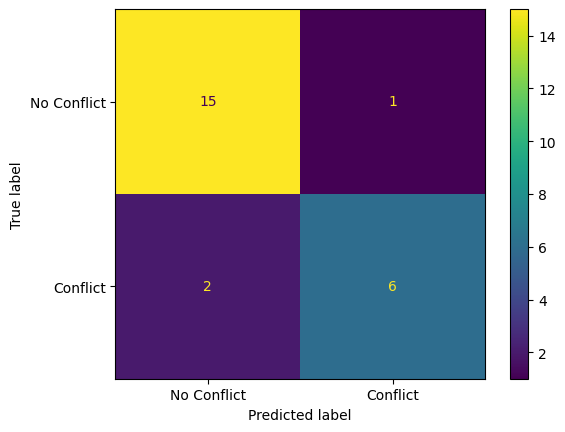

In [3]:
if Path('../data/processed/gemma_labels_v2.csv').exists():
    v2_labels = pd.read_csv('../data/processed/gemma_labels_v2.csv')
    v2_random_sample_labels = pd.read_csv('../data/processed/gemma_random_labels_v2.csv')
else:
    pass1 = ModelEvaluator(
        system_prompt=PASS1_PROMPT,
        response_schema=Pass1Response, temperature=0, num_retries=2, timeout=100
    )
    pass2 = ModelEvaluator(
        system_prompt=PASS2_PROMPT,
        response_schema=Pass2Response, temperature=0, num_retries=2, timeout=100
    )
    
    v2_labels = run_two_pass(subset, pass1, pass2, run_name='gemma_two_pass_v2')
    v2_random_sample_labels = run_two_pass(random_sample_df, pass1, pass2, 'gemma_random_labels_v2')

merged_data_v2 = pd.merge(
    v2_labels,
    manual_labels.loc[:, ['example_id', 'human_label', 'human_notes', 'Conflict_Found_GT']],
    how='inner', on='example_id'
)
score_against_human(merged_data_v2)

In [12]:
merged_data_v2[merged_data_v2.example_id == 1163642].iloc[0].product_features

['Kodak Premium Photo Paper', 'Gloss Finish', '8.5” x 11”', 'White']

In [11]:
merged_data_v2[merged_data_v2.example_id == 1163642].iloc[0].feature_alignment

[{'dimension': 'Core Product',
  'query_feature': 'photo paper',
  'product_feature': 'Kodak Premium Photo Paper',
  'status': 'match',
  'explaination': 'The product is explicitly Kodak Premium Photo Paper'},
 {'dimension': 'Size',
  'query_feature': '8.5 x 11',
  'product_feature': '8.5” x 11”',
  'status': 'match',
  'explaination': 'The product is explicitly 8.5” x 11”'},
 {'dimension': 'Finish',
  'query_feature': 'glossy',
  'product_feature': 'Gloss Finish',
  'status': 'match',
  'explaination': 'The product is explicitly Gloss Finish'},
 {'dimension': 'Color',
  'query_feature': 'glossy',
  'product_feature': 'White',
  'status': 'contradiction',
  'explaination': 'The product is explicitly White'}]

**As seen below, we can make prompt updates to give better instructions on how the reformulated query is formed. Copy over from pass 1**

In [13]:
show(merged_data_v2[merged_data_v2.conflict_found == True].head(3))

,example_id,query,title,human_label,Conflict_Found_GT,conflict_found,reasoning,reformulated_query,error
7,142666,aa batteries 100 pack,"Amazon Basics 100 Pack AAA High-Performance Alkaline Batteries, 10-Year Shelf Life, Easy to Open Value Pack",S,True,True,"The contradiction flagged as 'Dimension: Voltage' is a genuine conflict. The query asks for 'aa batteries', which implies a voltage of 1.5V. The product explicitly states '1.5 volt', representing a different voltage value. This is a numerical difference, indicating a genuine conflict. Other contradictions are false alarms because they involve different notations for the same value or type.",aa batteries 1.5v 100 pack,None
8,660823,"dewalt 8v max cordless screwdriver kit, gyroscopic","DEWALT XTREME 12V MAX Cordless Screwdriver, 1/4-Inch, Tool Only (DCF601B)",S,True,True,"The contradiction between '8v max' and '12V MAX' is a genuine conflict because they represent different numerical values for voltage. The contradiction between 'cordless screwdriver kit' and 'Cordless Screwdriver' is a genuine conflict because the product is a screwdriver and not a kit. The 'gyroscopic' feature is missing, but this is not a contradiction, it is simply a missing feature.",dewalt 8v cordless screwdriver kit gyroscopic,None
9,660827,"dewalt 8v max cordless screwdriver kit, gyroscopic","ENERTWIST Cordless Screwdriver, 8V Max 10Nm Electric Screwdriver Rechargeable Set with 82 Accessory Kit and Charger in Carrying Case, 21+1 Cluth, Dual Position Handle, LED Light, ET-CS-8",S,True,True,"The contradiction flagged between 'Brand' is a genuine conflict. The query specifies 'dewalt' as the brand, while the product is listed as 'ENERTWIST'. These are different brands, representing a mismatch. The 'Gyroscope' feature is flagged as 'missing', but the query includes 'gyroscopic'. This is an unrelated comparison of a feature that doesn't exist in the product description against a descriptor of that feature. This is a false alarm.",dewalt 8v max cordless screwdriver kit with gyroscope,None


In [7]:
show(merged_data_v2[merged_data_v2.conflict_found != merged_data_v2.Conflict_Found_GT])

,example_id,query,title,human_label,Conflict_Found_GT,conflict_found,reasoning,reformulated_query,error
4,142660,aa batteries 100 pack,"Rayovac AA Alkaline Double A Batteries, 60 Count",S,True,False,"The contradiction flagged for 'Quantity' is a false alarm. The query asks for a '100 pack', which can be interpreted as '100 batteries'. The product offers '60 Count', which is equivalent to 60 batteries. These are different numbers, but the difference is in the units (pack vs. count), not the numerical value itself. Therefore, it's not a genuine conflict. All other dimensions are correctly aligned and do not present any conflicts.",aa batteries 100,None
5,142661,aa batteries 100 pack,Energizer AA Max Alkaline E91 Batteries Made in USA - Expiration 12/2024 or Later - 100 Count,S,True,False,No contradictions found,None,None
22,1163642,kodak photo paper 8.5 x 11 glossy,"Kodak Premium Photo Paper for inkjet printers, Gloss Finish, 8.5 mil thickness, 50 Sheets, 8.5” x 11” (8360513),White",E,False,True,"The contradiction flagged is between 'Color' and 'Finish'. The query asks for 'glossy' paper, and the product specifies 'White' as the color. While 'glossy' implies a certain finish, the product explicitly states the color is white. This is a genuine conflict because the color and finish are different.",kodak glossy photo paper 8.5 x 11,None


In [5]:
# Checking a random sample
show(v2_random_sample_labels, display_cols= ["example_id", "query", "title", "conflict_found", "reasoning", "reformulated_query", "error"])

,example_id,query,title,conflict_found,reasoning,reformulated_query,error
0,2498421,収納ボックス,アイリスオーヤマ チェスト ワイド 3段 日本製 完成品 幅54×奥行40×高さ62.5cm ホワイト / クリア 白 プラスチック天板 W-543,False,"The contradiction flagged is between '収納ボックス' (storage box) and 'チェスト' (chest). This is a false alarm. 'チェスト' is a type of storage box. The core difference is the specific type of storage box, not a fundamental conflict in the product being a storage solution.",storage box,None
1,706866,dr martens mujer plataforma,"Botas para mujer, color Negro , marca DR. MARTENS, modelo Botas Para Mujer DR. MARTENS SINCLAIR 8 EYE AUNT S Negro",False,No contradictions found,None,None
2,1982138,tempered glass privacy screen iphone xr,"Hizansa [2 Pack] iPhone Xs Max Screen Protector,6D Tempered Glass Screen Protector for iPhone Xs Max (iPhone Xs Max)",True,"The contradiction flagged is 'Dimension: Phone Model | Query Value: iphone xr -> Product Value: iPhone XS Max -> Status: contradiction -> Explaination: The product is designed for iPhone XS Max, not iPhone XR.' This is a genuine conflict. The query specifically asks for a screen protector for the iPhone XR, and the product is listed as being for the iPhone XS Max. These are different phone models. I will set conflict_found to True and reformulate the query to focus on the iPhone XR specifically.",tempered glass privacy screen for iphone xr,None
3,313103,belly button rings,EVELICAL 15Pcs 14G Stainless Steel Belly Button Rings for Women Girls CZ Screw Navel Bars Body Piercing Jewelry,False,No contradictions found,None,None
4,2512267,存在のたえられない軽さ,存在の耐えられない軽さ(字幕版),False,No contradictions found,None,None


**Example of the iphone tempered glass**
Conflict was correctly found, but the reformulated query was incorrect


Code files:
1. [`response_schema.py`](../src/schemas/response_schema.py): Pydantic Schema
2. [`llm.py`](../src/llm.py): Wrapper around litellm
3. [`evaluation.py`](../src/evalution.py): Eval Code
4. [`prompts.py`](../src/prompts.py): Prompts

#### Future Recommendations
1. Improve examples and instructions to reformulate the query 
2. Async to speed up queries
3. Try larger models (we can also just try the larger model for pass 2 for better reasoning and final judgement)